In [12]:
import numpy as np
import os
import pandas as pd
from tqdm import tqdm
from pathlib import Path

In [13]:
path = Path('/Users/S4160163/Documents/Projects/RAG Paper/data/cic-iot/CSV')

In [14]:
################################################################################
# Remove columns with mean 0 and remove duplicate rows
################################################################################

# path = Path('/Users/S4160163/Documents/Projects/RAG Paper/data/cic-iot/')
dfs = []

# Recursively find all CSV files in subdirectories
for csv_file in tqdm(path.rglob('*.csv'), ncols=100, desc='Reading CSVs...'):
    df_temp = pd.read_csv(csv_file)
    # Extract label from directory name (same approach as 0-analysis.ipynb)
    # label = csv_file.parent.name.replace('_Final', '')
    # df_temp['label'] = label

    # Sample up to 100000 rows (with replacement if file is smaller)
    sample_size = min(100000, len(df_temp))
    dfs.append(df_temp.sample(n=sample_size, random_state=42, replace=(len(df_temp) < 100000)))
    print(f"Sampled {sample_size} rows from {csv_file}")

if not dfs:
    raise FileNotFoundError(f"No CSV files found in {path}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows in combined dataset: {len(df)}")

# remove columns if mean is 0
columns_to_drop = []
for c in df.select_dtypes(include=[np.number]).columns:
    if df[c].mean() == 0:
        columns_to_drop.append(c)
print("Columns to drop: ", columns_to_drop)

# get df with removed columns
df_with_dropped_columns = df.drop(columns_to_drop, axis=1)
print("Number of columns before removing columns: ", len(df.columns))
print("Number of columns after removing columns: ", len(df_with_dropped_columns.columns))

# remove duplicate rows
df_no_duplicates = df_with_dropped_columns.drop_duplicates()
print("Length of dataset before removing duplicates: ", len(df_with_dropped_columns))
print("Length of dataset after removing duplicates: ", len(df_no_duplicates))

# Create data directory if it doesn't exist
os.makedirs(os.getcwd() + '/data', exist_ok=True)
print(f"Data directory created at: {os.getcwd() + '/data'}")

# save to csv
df_no_duplicates.to_csv(os.getcwd() + '/data/population.csv', index=False)
print(f"Combined dataset saved to: {os.getcwd() + '/data/population.csv'}")

Reading CSVs...: 1it [00:02,  2.77s/it]

Sampled 100000 rows from /Users/S4160163/Documents/Projects/RAG Paper/data/cic-iot/CSV/cic-iot-2023-population.csv
Total rows in combined dataset: 100000
Columns to drop:  ['ece_flag_number', 'cwr_flag_number', 'DHCP']
Number of columns before removing columns:  44
Number of columns after removing columns:  41
Length of dataset before removing duplicates:  100000
Length of dataset after removing duplicates:  100000
Data directory created at: /Users/S4160163/Documents/Projects/RAG Paper/iot-llm-hids-pg/1-cic-iot/data


Combined dataset saved to: /Users/S4160163/Documents/Projects/RAG Paper/iot-llm-hids-pg/1-cic-iot/data/population.csv


In [15]:
################################################################################
# SECTION 2: Semantic Class Grouping & Balanced Multi-Class Sampling
################################################################################

import os
import pandas as pd
import numpy as np
from tabulate import tabulate

df = pd.read_csv(os.getcwd() + '/data/population.csv', low_memory=False)

# ── Step 1: Define semantic group mappings ----------------------------------------
# Attack sub-types within the same protocol-level category are merged into
# semantic families. This prevents within-family classification artefacts from
# dominating evaluation metrics and produces semantically distinct classes for
# LLM policy generation.

SEMANTIC_GROUPS = {
    # Each key is the new merged label; value is the list of raw labels
    'BenignTraffic':       ['BenignTraffic'],
    'DDoS-Flood':          ['DDoS-ICMP_Flood', 'DDoS-UDP_Flood', 'DDoS-TCP_Flood',
                            'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood',
                            'DDoS-SynonymousIP_Flood'],
    'DoS-Flood':           ['DoS-UDP_Flood', 'DoS-TCP_Flood', 'DoS-SYN_Flood'],
    'Mirai':               ['Mirai-greeth_flood', 'Mirai-udpplain', 'Mirai-greip_flood'],
    'DDoS-Fragmentation':  ['DDoS-ICMP_Fragmentation', 'DDoS-ACK_Fragmentation',
                            'DDoS-UDP_Fragmentation'],
    'MITM-ArpSpoofing':    ['MITM-ArpSpoofing'],
    'DNS_Spoofing':        ['DNS_Spoofing'],
    'Recon':               ['Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PortScan'],
}

# Classes below this threshold are statistically indefensible at an 80/20 split
MIN_CLASS_COUNT = 200

# ── Step 2: Build reverse map (raw label → group name) ───────────────────────
raw_to_group = {}
for group_name, raw_labels in SEMANTIC_GROUPS.items():
    for raw_label in raw_labels:
        raw_to_group[raw_label] = group_name

# ── Step 3: Map labels in dataframe ──────────────────────────────────────────
df['label_group'] = df['label'].map(raw_to_group)

# Drop rows whose original label doesn't belong to any defined group
# (these are either the <200 classes or any label not in our taxonomy)
df_grouped = df.dropna(subset=['label_group']).copy()
df_grouped['label'] = df_grouped['label_group']
df_grouped = df_grouped.drop(columns=['label_group'])

# ── Step 4: Report pre-sampling group sizes ───────────────────────────────────
print("\nPre-sampling class distribution:")
group_counts = df_grouped['label'].value_counts().sort_values(ascending=False)
pre_sample_data = [[lbl, cnt, f"{cnt/len(df_grouped)*100:.2f}%"]
                   for lbl, cnt in group_counts.items()]
print(tabulate(pre_sample_data,
               headers=["Group Label", "Count", "Percentage"],
               tablefmt="grid"))

# ── Step 5: Enforce minimum count floor ──────────────────────────────────────
valid_groups = group_counts[group_counts >= MIN_CLASS_COUNT].index.tolist()
df_filtered = df_grouped[df_grouped['label'].isin(valid_groups)].copy()

removed = set(group_counts.index) - set(valid_groups)
if removed:
    print(f"\nGroups removed (count < {MIN_CLASS_COUNT}): {removed}")

# ── Step 6: Cap at BenignTraffic count ───────────────────────────────────────
# BenignTraffic size sets the sampling ceiling for all attack classes.
# This mirrors the principle that benign traffic acts as the reference
# distribution and prevents attack families from dominating.
benign_count = len(df_filtered[df_filtered['label'] == 'BenignTraffic'])
CAP = benign_count
print(f"\nSampling cap (set to BenignTraffic count): {CAP}")

sampled_dfs = []
for label in df_filtered['label'].unique():
    class_df = df_filtered[df_filtered['label'] == label]
    n = min(CAP, len(class_df))
    sampled_dfs.append(class_df.sample(n=n, random_state=42, replace=False))

sample_df = pd.concat(sampled_dfs, ignore_index=True)

# ── Step 7: Report final sample ──────────────────────────────────────────────
print("\nFinal balanced multi-class sample distribution:")
final_counts = sample_df['label'].value_counts().sort_values(ascending=False)
final_data = [[lbl, cnt, f"{cnt/len(sample_df)*100:.2f}%"]
              for lbl, cnt in final_counts.items()]
print(tabulate(final_data,
               headers=["Group Label", "Count", "Percentage"],
               tablefmt="grid"))
print(f"\nTotal records in sample: {len(sample_df)}")
print(f"Number of distinct classes: {sample_df['label'].nunique()}")

# ── Step 8: Save ─────────────────────────────────────────────────────────────
os.makedirs(os.getcwd() + '/data', exist_ok=True)
sample_df.to_csv(os.getcwd() + '/data/sample-multiclass.csv', index=False)
print("\nSaved to: data/sample-multiclass.csv")


Pre-sampling class distribution:
+--------------------+---------+--------------+
| Group Label        |   Count | Percentage   |
+====================+=========+==============+
| DDoS-Flood         |   70368 | 70.71%       |
+--------------------+---------+--------------+
| DoS-Flood          |   17178 | 17.26%       |
+--------------------+---------+--------------+
| Mirai              |    5701 | 5.73%        |
+--------------------+---------+--------------+
| BenignTraffic      |    2348 | 2.36%        |
+--------------------+---------+--------------+
| DDoS-Fragmentation |    2163 | 2.17%        |
+--------------------+---------+--------------+
| Recon              |     705 | 0.71%        |
+--------------------+---------+--------------+
| MITM-ArpSpoofing   |     653 | 0.66%        |
+--------------------+---------+--------------+
| DNS_Spoofing       |     405 | 0.41%        |
+--------------------+---------+--------------+

Sampling cap (set to BenignTraffic count): 2348

Fina

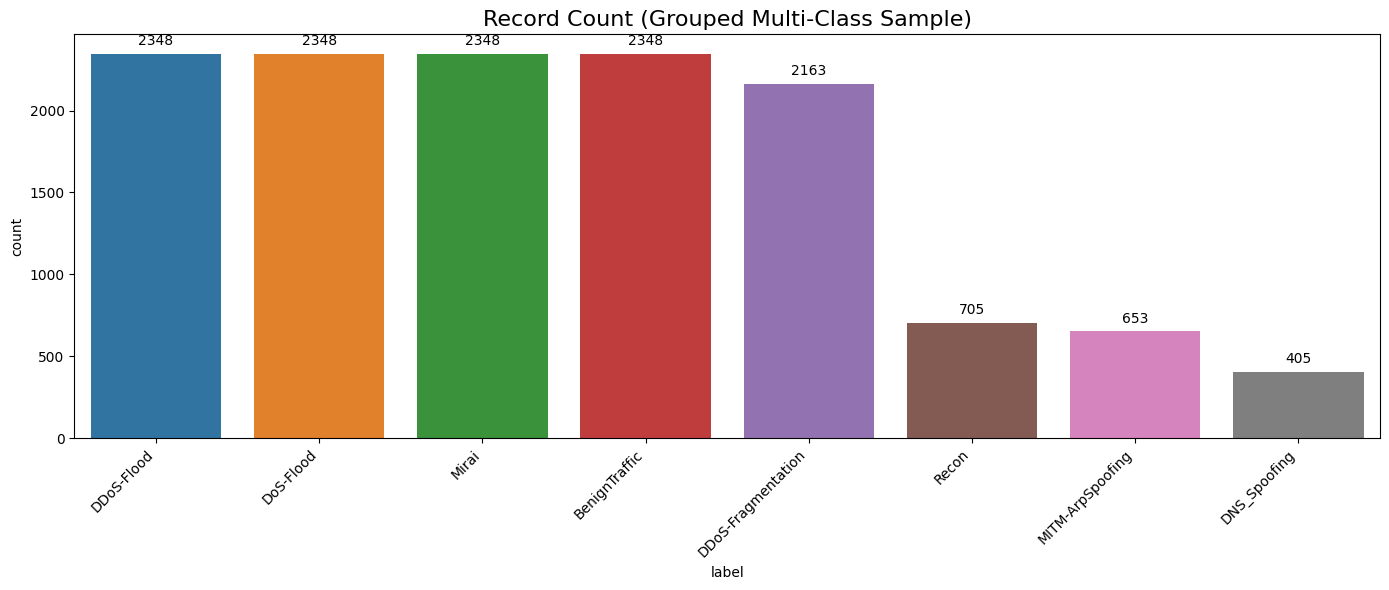

In [16]:
################################################################################
# SECTION 3: Class Distribution Visualisation (multi-class)
################################################################################

import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

sample_df = pd.read_csv(os.getcwd() + '/data/sample-multiclass.csv', low_memory=False)

plt.figure(figsize=(14, 6))
plt.xticks(rotation=45, ha='right')
s = sns.countplot(data=sample_df, x='label', hue='label',
                  order=sample_df['label'].value_counts().index)
for p in s.patches:
    s.annotate(format(p.get_height(), '.0f'),
               (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='center',
               xytext=(0, 9),
               textcoords='offset points')
plt.title('Record Count (Grouped Multi-Class Sample)', fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
################################################################################
# SECTION 4: Stratified Multi-Class Train / Test Split
################################################################################

import pandas as pd
import os
from tabulate import tabulate

sample_df = pd.read_csv(os.getcwd() + '/data/sample-multiclass.csv', low_memory=False)

train_dfs = []
test_dfs  = []

for label in sample_df['label'].unique():
    class_df = sample_df[sample_df['label'] == label]
    train_part = class_df.sample(frac=0.8, random_state=42)
    test_part  = class_df.drop(train_part.index)
    train_dfs.append(train_part)
    test_dfs.append(test_part)

train_df = pd.concat(train_dfs, ignore_index=True)
test_df  = pd.concat(test_dfs,  ignore_index=True)

# Save splits (label column is retained for multi-class evaluation)
train_df.to_csv(os.getcwd() + '/data/train-multiclass.csv', index=False)
test_df.to_csv(os.getcwd() + '/data/test-multiclass.csv',  index=False)

# Report
report_data = []
for label in sorted(sample_df['label'].unique()):
    total = len(sample_df[sample_df['label'] == label])
    tr    = len(train_df[train_df['label'] == label])
    te    = len(test_df[test_df['label'] == label])
    report_data.append([label, total, tr, te])

report_data.append(['── TOTAL ──', len(sample_df), len(train_df), len(test_df)])
print(tabulate(report_data,
               headers=["Class", "Total", "Train (80%)", "Test (20%)"],
               tablefmt="grid"))

+--------------------+---------+---------------+--------------+
| Class              |   Total |   Train (80%) |   Test (20%) |
+====================+=========+===============+==============+
| BenignTraffic      |    2348 |          1878 |          470 |
+--------------------+---------+---------------+--------------+
| DDoS-Flood         |    2348 |          1878 |          470 |
+--------------------+---------+---------------+--------------+
| DDoS-Fragmentation |    2163 |          1730 |          433 |
+--------------------+---------+---------------+--------------+
| DNS_Spoofing       |     405 |           324 |           81 |
+--------------------+---------+---------------+--------------+
| DoS-Flood          |    2348 |          1878 |          470 |
+--------------------+---------+---------------+--------------+
| MITM-ArpSpoofing   |     653 |           522 |          131 |
+--------------------+---------+---------------+--------------+
| Mirai              |    2348 |        

In [20]:
################################################################################
# SECTION 5: Add Documents to Vector Store (Train Set — Multi-Class)
################################################################################

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from tqdm import tqdm
import pandas as pd
import os

sample_size = 'multiclass'

train_df = pd.read_csv(os.getcwd() + '/data/train-multiclass.csv', low_memory=False)

# Initialise embeddings and vector store
embeddings = HuggingFaceEmbeddings(
    model_name='BAAI/bge-m3',
    model_kwargs={'device': 'mps'},
    encode_kwargs={'normalize_embeddings': True, 'batch_size': 64}
)
vector_store = Chroma(
    collection_name="cic-iot-multiclass-train",
    embedding_function=embeddings,
    persist_directory=f"./vector-stores/chroma-db-{sample_size}-bge-m3-train"
)

batch_size = 16
total_added = 0

for label in train_df['label'].unique():
    class_df = train_df[train_df['label'] == label].drop(columns=['label'])
    total_rows = len(class_df)

    for i in tqdm(range(0, total_rows, batch_size),
                  ncols=100,
                  desc=f"Adding [{label}] to train store"):
        batch = class_df.iloc[i : i + batch_size]
        documents = [
            Document(
                page_content=str(row.to_list()),
                metadata={"source": "cic-iot-train", "label": label}
            )
            for _, row in batch.iterrows()
        ]
        vector_store.add_documents(documents)
        total_added += len(documents)

print(f"\nTotal documents added to train vector store: {total_added}")

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Adding [DNS_Spoofing] to train store: 100%|█████████████████████████| 21/21 [00:25<00:00,  1.22s/it]


Total documents added to train vector store: 10652


In [21]:
################################################################################
# SECTION 6: Add Documents to Vector Store (Test Set — Multi-Class)
################################################################################

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from tqdm import tqdm
import pandas as pd
import os

sample_size = 'multiclass'

test_df = pd.read_csv(os.getcwd() + '/data/test-multiclass.csv', low_memory=False)

# Initialise embeddings and vector store
embeddings = HuggingFaceEmbeddings(
    model_name='BAAI/bge-m3',
    model_kwargs={'device': 'mps'},
    encode_kwargs={'normalize_embeddings': True, 'batch_size': 64}
)
vector_store = Chroma(
    collection_name="cic-iot-multiclass-test",
    embedding_function=embeddings,
    persist_directory=f"./vector-stores/chroma-db-{sample_size}-bge-m3-test"
)

batch_size = 16
total_added = 0

for label in test_df['label'].unique():
    class_df = test_df[test_df['label'] == label].drop(columns=['label'])
    total_rows = len(class_df)

    for i in tqdm(range(0, total_rows, batch_size),
                  ncols=100,
                  desc=f"Adding [{label}] to test store"):
        batch = class_df.iloc[i : i + batch_size]
        documents = [
            Document(
                page_content=str(row.to_list()),
                metadata={"source": "cic-iot-test", "label": label}
            )
            for _, row in batch.iterrows()
        ]
        vector_store.add_documents(documents)
        total_added += len(documents)

print(f"\nTotal documents added to test vector store: {total_added}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Adding [DNS_Spoofing] to test store: 100%|████████████████████████████| 6/6 [00:06<00:00,  1.12s/it]


Total documents added to test vector store: 2666


# Old Code

In [9]:
################################################################################
# Split and save dataset
################################################################################

import os
import pandas as pd

# Create data directory if it doesn't exist
os.makedirs(os.getcwd() + '/data', exist_ok=True)

df = pd.read_csv(os.getcwd() + '/data/population.csv', low_memory=False)

sample_size = 100000

benign_df = df[df['label'] == 'BenignTraffic']
attack_df = df[df['label'] != 'BenignTraffic']

# Keep original class ratio target, but avoid crashing when one class is smaller than requested
benign_target = min(10800, len(benign_df))
attack_target = min(sample_size - benign_target, len(attack_df))

sample_df = pd.concat([
    benign_df.sample(n=benign_target, random_state=42, replace=False),
    attack_df.sample(n=attack_target, random_state=42, replace=False)
])

print("Length of dataset: ", len(sample_df))
print(f"Sample saved to: {os.getcwd() + f'/data/sample-{sample_size}-2.csv'}")
sample_df.to_csv(os.getcwd() + f'/data/sample-{sample_size}-2.csv', index=False)

Length of dataset:  100000
Sample saved to: /Users/S4160163/Documents/Projects/RAG Paper/iot-llm-hids-pg/1-cic-iot/data/sample-100000-2.csv



Class Distribution Table:
+-------------------------+---------+--------------+
| Label                   |   Count |   Percentage |
+=========================+=========+==============+
| DDoS-ICMP_Flood         |   15335 |        15.34 |
+-------------------------+---------+--------------+
| DDoS-UDP_Flood          |   11509 |        11.51 |
+-------------------------+---------+--------------+
| DDoS-TCP_Flood          |    9566 |         9.57 |
+-------------------------+---------+--------------+
| DDoS-PSHACK_Flood       |    8817 |         8.82 |
+-------------------------+---------+--------------+
| DDoS-RSTFINFlood        |    8741 |         8.74 |
+-------------------------+---------+--------------+
| DDoS-SYN_Flood          |    8646 |         8.65 |
+-------------------------+---------+--------------+
| DDoS-SynonymousIP_Flood |    7754 |         7.75 |
+-------------------------+---------+--------------+
| DoS-UDP_Flood           |    7194 |         7.19 |
+------------------

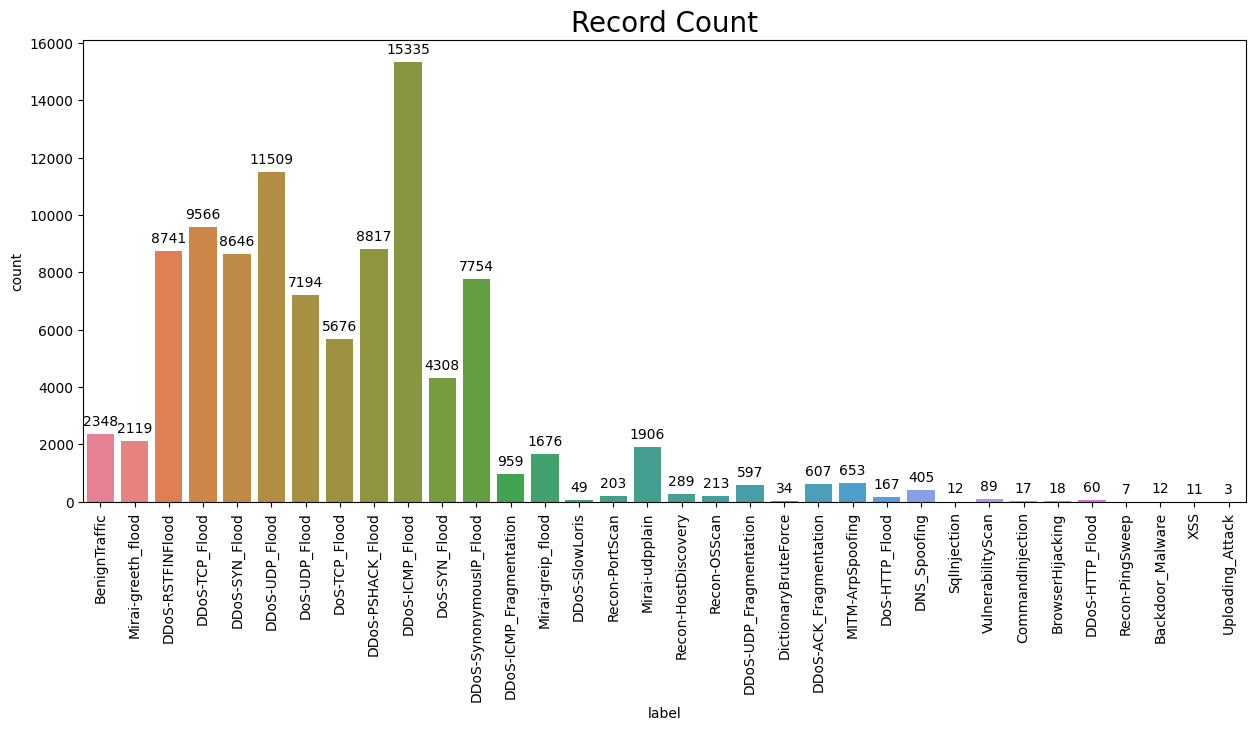

In [11]:
################################################################################
# Class distribution
################################################################################

import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from tabulate import tabulate

sample_size = 100000

saved_sample_df = pd.read_csv(os.getcwd() + f'/data/sample-{sample_size}-2.csv', low_memory=False)

plt.figure(figsize=(15, 6))
plt.xticks(rotation=90)
s = sns.countplot(data=saved_sample_df, x='label', hue='label')
for p in s.patches:
    s.annotate(format(p.get_height(), '.0f'), 
               (p.get_x() + p.get_width() / 2., p.get_height()), 
               ha = 'center', va = 'center', 
               xytext = (0, 9), 
               textcoords = 'offset points')
plt.title('Record Count', fontsize=20)

# Display class distribution as a table
print("\nClass Distribution Table:")
label_counts = saved_sample_df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(saved_sample_df) * 100).round(2)
print(tabulate(label_counts, headers='keys', tablefmt='grid', showindex=False))

In [6]:
################################################################################
# Load dataset and split it into training and test set
################################################################################

import pandas as pd
import os
from tabulate import tabulate

sample_size = 100000

# Load dateset
df = pd.read_csv(os.getcwd() + f'/data/sample-{sample_size}-2.csv')

# Split dataset according to attack type
normal_df = df[df['label'] == 'BenignTraffic']
attack_df = df[df['label'] != 'BenignTraffic']

# Drop columns
normal_df = normal_df.drop(columns=['label'])
attack_df = attack_df.drop(columns=['label'])

# Split dataset into training and test set
normal_df_train = normal_df.sample(frac=0.8, random_state=42)
normal_df_test = normal_df.drop(normal_df_train.index)
attack_df_train = attack_df.sample(frac=0.8, random_state=42)
attack_df_test = attack_df.drop(attack_df_train.index)

# Print dataset sizes in a table
data = [
    ["Normal", normal_df.shape[0], normal_df_train.shape[0], normal_df_test.shape[0]],
    ["Attack", attack_df.shape[0], attack_df_train.shape[0], attack_df_test.shape[0]]
]
print(tabulate(data, headers=["Attack type", "Total", "Train", "Test"], tablefmt="grid"))

+---------------+---------+---------+--------+
| Attack type   |   Total |   Train |   Test |
+===============+=========+=========+========+
| Normal        |     304 |     243 |     61 |
+---------------+---------+---------+--------+
| Attack        |     311 |     249 |     62 |
+---------------+---------+---------+--------+


In [ ]:
################################################################################
# Add documents to vector store (train set)
################################################################################

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from tqdm import tqdm
import numpy as np

sample_size = 100000

# Initialize embeddings using HuggingFaceEmbeddings (proper wrapper for Chroma)
embeddings = HuggingFaceEmbeddings(model_name='all-mpnet-base-v2')

# Initialize vector store
vector_store = Chroma(
    collection_name="cic-iot",
    embedding_function=embeddings, 
    persist_directory=f"./vector-stores/chroma-db-{sample_size}-2")

# Add batched documents to vector store
batch_size = 16
total_normal_documents = normal_df_train.shape[0]
total_attack_documents = attack_df_train.shape[0]

for i in tqdm(range(0, total_normal_documents, batch_size), ncols=100, desc="Adding normal documents to vector store"):
    documents = [Document(page_content=str(normal_df_train.iloc[i+j].to_list()), metadata={"source": "cic-iot", "label": "normal"}) for j in range(min(batch_size, total_normal_documents-i))]
    vector_store.add_documents(documents)

for i in tqdm(range(0, total_attack_documents, batch_size), ncols=100, desc="Adding attack documents to vector store"):
    documents = [Document(page_content=str(attack_df_train.iloc[i+j].to_list()), metadata={"source": "cic-iot", "label": "attack"}) for j in range(min(batch_size, total_attack_documents-i))]
    vector_store.add_documents(documents)

print(f"Total number of documents added: {total_attack_documents+total_normal_documents}")

Adding attack documents to vector store: 100%|██████████████████████| 16/16 [00:06<00:00,  2.43it/s]

Total number of documents added: 492


In [8]:
################################################################################
# Add documents to vector store (test set)
################################################################################

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from tqdm import tqdm
import numpy as np

# Initialize embeddings using HuggingFaceEmbeddings (proper wrapper for Chroma)
embeddings = HuggingFaceEmbeddings(model_name='all-mpnet-base-v2')

# Initialize vector store
vector_store = Chroma(
    collection_name="cic-iot-test",
    embedding_function=embeddings, 
    persist_directory=f"./vector-stores/chroma-db-{sample_size}-2-test")

# Add batched documents to vector store
batch_size = 16
total_normal_documents = normal_df_test.shape[0]
total_attack_documents = attack_df_test.shape[0]

for i in tqdm(range(0, total_normal_documents, batch_size), ncols=100, desc="Adding normal documents to vector store"):
    documents = [Document(page_content=str(normal_df_test.iloc[i+j].to_list()), metadata={"source": "cic-iot-test", "label": "normal"}) for j in range(min(batch_size, total_normal_documents-i))]
    vector_store.add_documents(documents)

for i in tqdm(range(0, total_attack_documents, batch_size), ncols=100, desc="Adding attack documents to vector store"):
    documents = [Document(page_content=str(attack_df_test.iloc[i+j].to_list()), metadata={"source": "cic-iot-test", "label": "attack"}) for j in range(min(batch_size, total_attack_documents-i))]
    vector_store.add_documents(documents)

print(f"Total number of documents added: {total_attack_documents+total_normal_documents}")

Adding attack documents to vector store: 100%|████████████████████████| 4/4 [00:01<00:00,  2.55it/s]

Total number of documents added: 123
